In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("dataset/customer_churn.csv")

In [8]:
df.head()

,Customer ID,Gender,Age,Tenure Months,Contract,Internet Service,Payment Method,Tech Support,Paperless Billing,Monthly Charges,Churn,Annual Revenue,Customer Segment
0,CUST-00001,Male,28,25,Month-to-month,DSL,Mailed check,No,Yes,105.61,No,1267.32,25-48 Months
1,CUST-00002,Female,19,16,One year,Fiber optic,Credit card,Yes,Yes,111.88,No,1342.56,13-24 Months
2,CUST-00003,Female,51,38,Month-to-month,Fiber optic,Electronic check,Yes,Yes,102.42,Yes,1229.04,25-48 Months
3,CUST-00004,Male,54,48,Month-to-month,No internet,Bank transfer,No,No,67.99,Yes,815.88,25-48 Months
4,CUST-00005,Male,58,19,Month-to-month,DSL,Mailed check,No,Yes,32.06,Yes,384.72,13-24 Months


In [9]:
df.shape


(5000, 13)

In [10]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Tenure Months', 'Contract',
       'Internet Service', 'Payment Method', 'Tech Support',
       'Paperless Billing', 'Monthly Charges', 'Churn', 'Annual Revenue',
       'Customer Segment'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        5000 non-null   object 
 1   Gender             5000 non-null   object 
 2   Age                5000 non-null   int64  
 3   Tenure Months      5000 non-null   int64  
 4   Contract           5000 non-null   object 
 5   Internet Service   5000 non-null   object 
 6   Payment Method     5000 non-null   object 
 7   Tech Support       5000 non-null   object 
 8   Paperless Billing  5000 non-null   object 
 9   Monthly Charges    5000 non-null   float64
 10  Churn              5000 non-null   object 
 11  Annual Revenue     5000 non-null   float64
 12  Customer Segment   5000 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 507.9+ KB


In [12]:
df.isnull().sum()

Customer ID          0
Gender               0
Age                  0
Tenure Months        0
Contract             0
Internet Service     0
Payment Method       0
Tech Support         0
Paperless Billing    0
Monthly Charges      0
Churn                0
Annual Revenue       0
Customer Segment     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Age,Tenure Months,Monthly Charges,Annual Revenue
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.683600,36.272600,72.391800,868.701600
std,15.112325,20.734943,27.372666,328.471997
min,18.000000,1.000000,20.000000,240.000000
25%,31.000000,19.000000,53.077500,636.930000
50%,44.000000,36.000000,71.855000,862.260000
75%,57.000000,54.000000,90.915000,1090.980000
max,70.000000,72.000000,160.000000,1920.000000


In [15]:
df['Churn'].value_counts()

Churn
No     3670
Yes    1330
Name: count, dtype: int64

In [16]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
churn_percentage

Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64

In [17]:
total_customers = df['Customer ID'].nunique()
churned_customers = (df['Churn'] == 'Yes').sum()
churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 5000
Churned Customers: 1330
Churn Rate: 26.6 %


In [6]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,65.112009,34.887991
One year,79.768340,20.231660
Two year,87.983707,12.016293


In [19]:
contract_churn['Yes'].sort_values(ascending=False)

Contract
Month-to-month    34.887991
One year          20.231660
Two year          12.016293
Name: Yes, dtype: float64

In [7]:
payment_churn = pd.crosstab(
    df['Payment Method'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn['Yes'].sort_values(ascending=False)

Payment Method
Electronic check    33.571855
Credit card         23.529412
Bank transfer       22.950820
Mailed check        22.757318
Name: Yes, dtype: float64

In [8]:
internet_churn = pd.crosstab(
    df['Internet Service'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn['Yes'].sort_values(ascending=False)

Internet Service
Fiber optic    31.836551
DSL            22.588348
No internet    21.796760
Name: Yes, dtype: float64

In [9]:
def create_tenure_group(months):
    if months <= 12:
        return '0-12 Months'
    elif months <= 24:
        return '13-24 Months'
    elif months <= 36:
        return '25-36 Months'
    elif months <= 48:
        return '37-48 Months'
    elif months <= 60:
        return '49-60 Months'
    else:
        return '60+ Months'

df['Tenure Group'] = df['Tenure Months'].apply(create_tenure_group)

In [10]:
tenure_churn = pd.crosstab(
    df['Tenure Group'],
    df['Churn'],
    normalize='index'
) * 100

tenure_churn['Yes']

Tenure Group
0-12 Months     30.465116
13-24 Months    27.620222
25-36 Months    26.738609
37-48 Months    24.829932
49-60 Months    24.120603
60+ Months      25.703794
Name: Yes, dtype: float64

In [27]:
tech_support_churn = pd.crosstab(
    df['Tech Support'],
    df['Churn'],
    normalize='index'
) * 100

tech_support_churn['Yes'].sort_values(ascending=False)

Tech Support
No     28.001017
Yes    21.441948
Name: Yes, dtype: float64

In [28]:
df.groupby('Churn')['Monthly Charges'].agg(
    ['mean', 'median', 'min', 'max']
)

,mean,median,min,max
Churn,,,,
No,72.362300,71.820,20.0,160.0
Yes,72.473203,71.945,20.0,160.0


In [29]:
df.groupby('Churn')['Monthly Charges'].mean()

Churn
No     72.362300
Yes    72.473203
Name: Monthly Charges, dtype: float64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

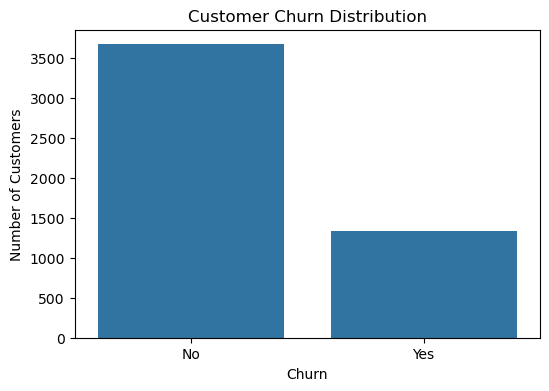

In [32]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

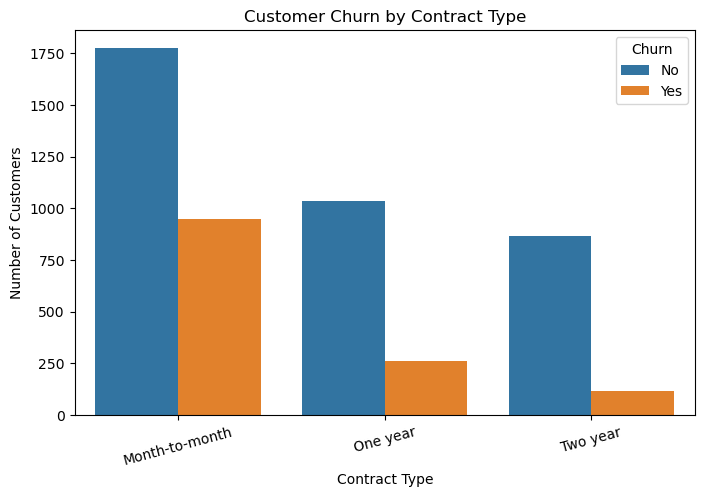

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.show()

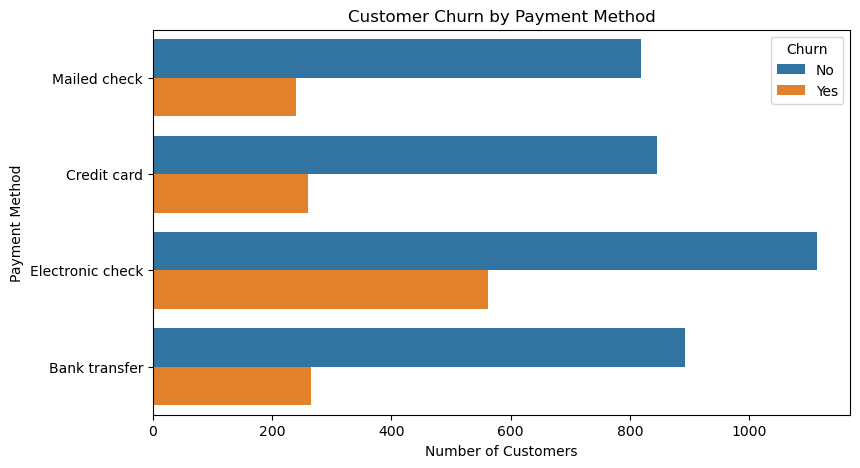

In [34]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    y='Payment Method',
    hue='Churn'
)

plt.title('Customer Churn by Payment Method')
plt.xlabel('Number of Customers')
plt.ylabel('Payment Method')

plt.show()

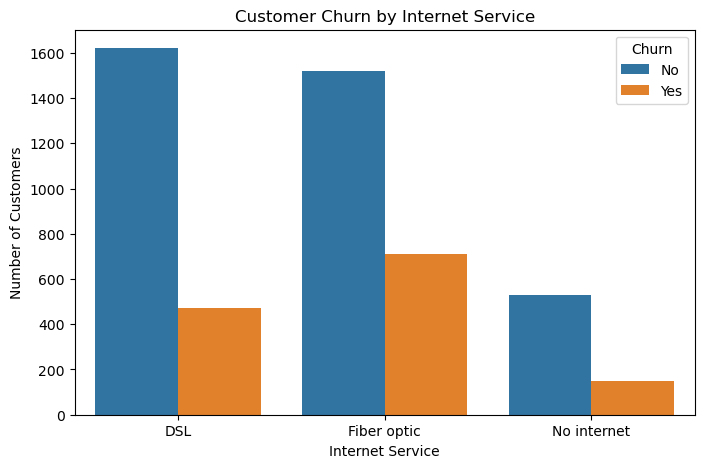

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Internet Service',
    hue='Churn'
)

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

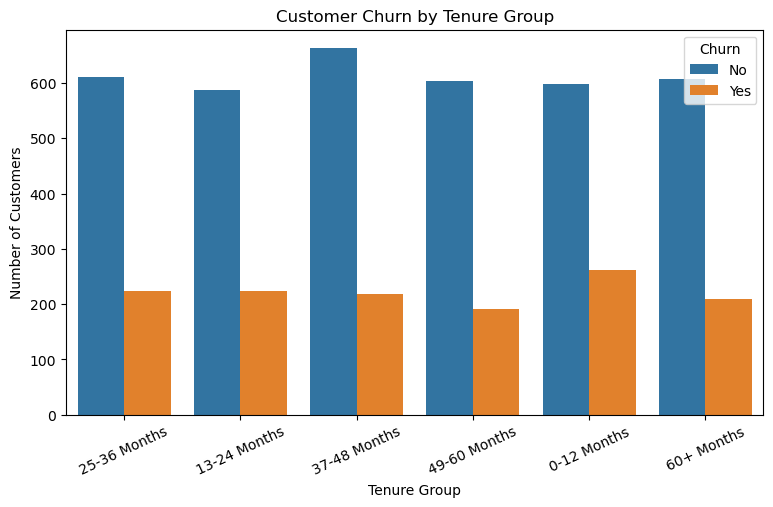

In [36]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Tenure Group',
    hue='Churn'
)

plt.title('Customer Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=25)

plt.show()

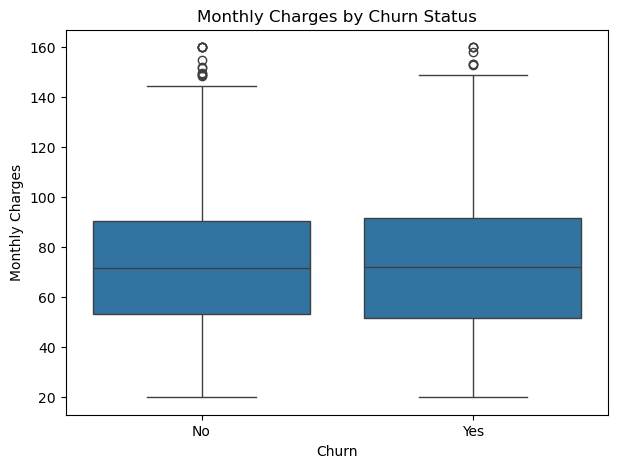

In [37]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Monthly Charges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

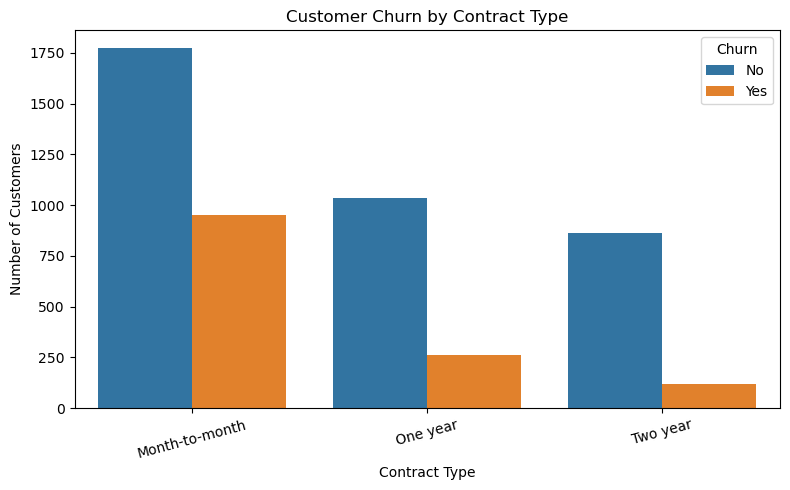

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig('screenshots/churn_by_contract.png', dpi=300)

plt.show()

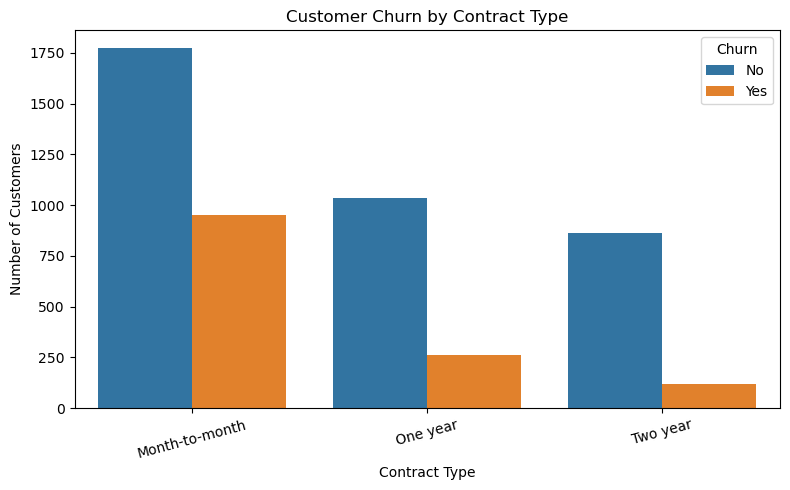

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig('screenshots/churn_by_contract.png', dpi=300)

plt.show()

In [11]:
internet_churn['Yes'].sort_values(ascending=False)

Internet Service
Fiber optic    31.836551
DSL            22.588348
No internet    21.796760
Name: Yes, dtype: float64

In [12]:
tenure_churn['Yes'].sort_values(ascending=False)

Tenure Group
0-12 Months     30.465116
13-24 Months    27.620222
25-36 Months    26.738609
60+ Months      25.703794
37-48 Months    24.829932
49-60 Months    24.120603
Name: Yes, dtype: float64

## Business Insights

1. The overall customer churn rate is 26.6%, with 1,330 out of 5,000 customers having churned.

2. Month-to-month customers have the highest churn rate at approximately 34.9%, while two-year contract customers have the lowest at approximately 12.0%.

3. Electronic check users have the highest churn rate among payment methods at approximately 33.6%.

4. Fiber optic customers have the highest churn rate among internet service types at approximately 31.84%.

5. Customers with 0-12 months of tenure have the highest churn rate at approximately 30.47%.

6. Churned customers have slightly higher average monthly charges ($72.47) than retained customers ($72.36), but the difference is very small.